In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

import joblib
import os
from pathlib import Path


## Load Dataset

In [2]:
df = pd.read_csv("../data/raw/inventory.csv")

df.head()

,date,drug_name,sales
0,2023-01-01,Paracetamol,97
1,2023-01-02,Paracetamol,107
2,2023-01-03,Paracetamol,109
3,2023-01-04,Paracetamol,105
4,2023-01-05,Paracetamol,92


## Data Preprocessing

In [3]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values("date")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       6000 non-null   datetime64[ns]
 1   drug_name  6000 non-null   object        
 2   sales      6000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 187.5+ KB


## Exploratory Data Analysis

In [4]:
df['drug_name'].unique()

array(['Paracetamol', 'Cetirizine', 'Amoxicillin', 'Azithromycin', 'ORS',
       'Pantoprazole', 'Metformin', 'Atorvastatin', 'Dolo650',
       'Ibuprofen'], dtype=object)

In [5]:
drug = "Paracetamol"

drug_df = df[df['drug_name']==drug]

drug_df = drug_df.sort_values("date")

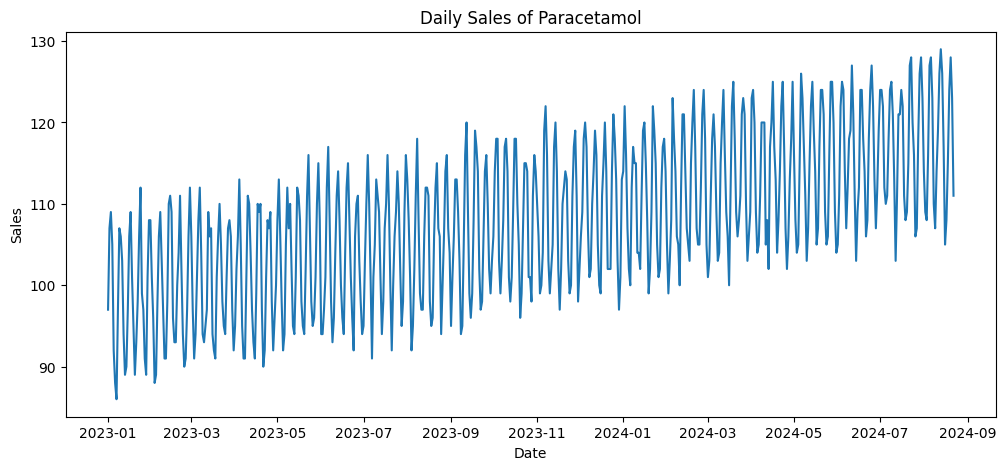

In [6]:
plt.figure(figsize=(12,5))

plt.plot(drug_df['date'], drug_df['sales'])

plt.title(f"Daily Sales of {drug}")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [7]:
drug_df = drug_df.set_index("date")

drug_df = drug_df.asfreq("D")

drug_df.head()

,drug_name,sales
date,,
2023-01-01,Paracetamol,97
2023-01-02,Paracetamol,107
2023-01-03,Paracetamol,109
2023-01-04,Paracetamol,105
2023-01-05,Paracetamol,92


## Train/Test Split

In [8]:
train = drug_df[:-30]

test = drug_df[-30:]

print("Train:",len(train))
print("Test:",len(test))

Train: 570
Test: 30


## Train ARIMA Model

In [9]:
model = ARIMA(train['sales'], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  570
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1404.866
Date:                Tue, 07 Apr 2026   AIC                           2821.731
Time:                        16:39:12   BIC                           2847.795
Sample:                    01-01-2023   HQIC                          2831.901
                         - 07-23-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4249      0.035    -11.993      0.000      -0.494      -0.355
ar.L2         -0.3076      0.029    -10.557      0.000      -0.365      -0.250
ar.L3         -0.5240      0.023    -22.956      0.0

In [10]:
predictions = model_fit.forecast(steps=len(test))

predictions

2024-07-24    121.744298
2024-07-25    113.400147
2024-07-26    107.337184
2024-07-27    108.525725
2024-07-28    117.730404
2024-07-29    125.430042
2024-07-30    127.183775
2024-07-31    121.811988
2024-08-01    112.950518
2024-08-02    107.444963
2024-08-03    109.969536
2024-08-04    117.724145
2024-08-05    125.183959
2024-08-06    126.711260
2024-08-07    121.104458
2024-08-08    112.736617
2024-08-09    108.162713
2024-08-10    110.540020
2024-08-11    118.087348
2024-08-12    125.004053
2024-08-13    126.033109
2024-08-14    120.496747
2024-08-15    112.750956
2024-08-16    108.615128
2024-08-17    111.196562
2024-08-18    118.424753
2024-08-19    124.746158
2024-08-20    125.396156
2024-08-21    119.999426
2024-08-22    112.715918
Freq: D, Name: predicted_mean, dtype: float64

## Evaluate Model Accuracy

In [11]:
mae = mean_absolute_error(test['sales'], predictions)

print("MAE:",mae)

MAE: 2.054647027124526


## Plot Prediction vs Actual

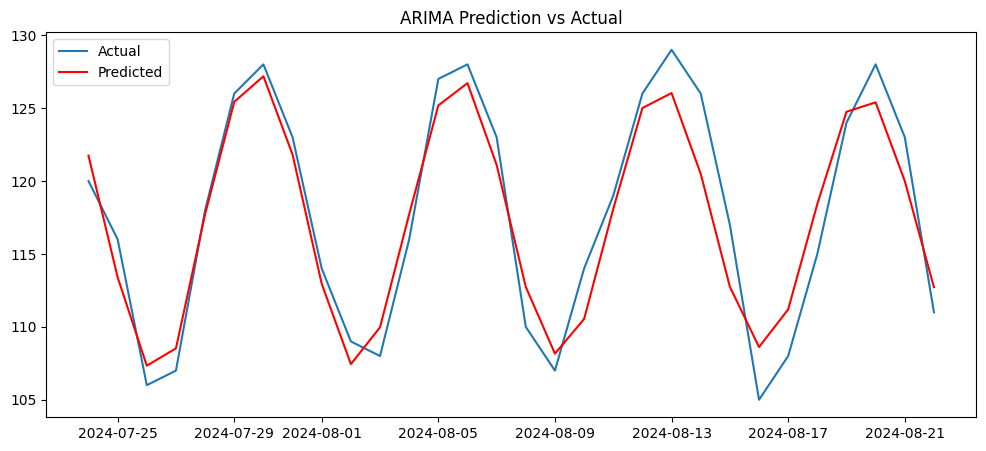

In [12]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test['sales'], label="Actual")

plt.plot(test.index, predictions, label="Predicted", color="red")

plt.legend()

plt.title("ARIMA Prediction vs Actual")

plt.show()

In [13]:
models = {}

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

for drug in df['drug_name'].unique():

    drug_df = df[df['drug_name']==drug]

    drug_df = drug_df.sort_values("date")

    drug_df = drug_df.set_index("date")

    drug_df = drug_df.asfreq("D")

    model = ARIMA(drug_df['sales'], order=(5,1,0))

    model_fit = model.fit()

    joblib.dump(model_fit, models_dir / f"{drug}_arima.pkl")

    models[drug] = model_fit

print("All models saved successfully")

All models saved successfully
